First 5 Rows:
      price  area  bedrooms  bathrooms  stories mainroad guestroom basement  \
0  13300000  7420         4          2        3      yes        no       no   
1  12250000  8960         4          4        4      yes        no       no   
2  12250000  9960         3          2        2      yes        no      yes   
3  12215000  7500         4          2        2      yes        no      yes   
4  11410000  7420         4          1        2      yes       yes      yes   

  hotwaterheating airconditioning  parking prefarea furnishingstatus  
0              no             yes        2      yes        furnished  
1              no             yes        3       no        furnished  
2              no              no        2      yes   semi-furnished  
3              no             yes        3      yes        furnished  
4              no             yes        2       no        furnished  

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 545 entries, 0 to 54

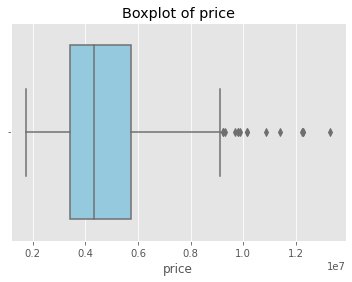

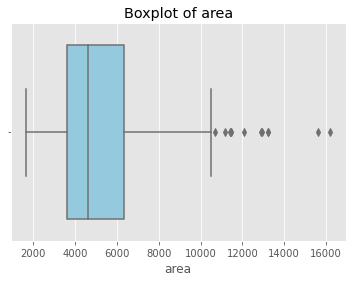

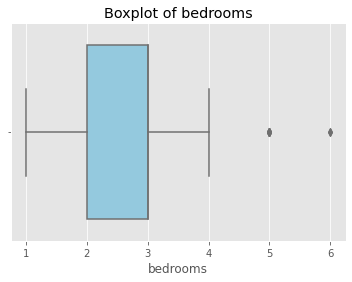

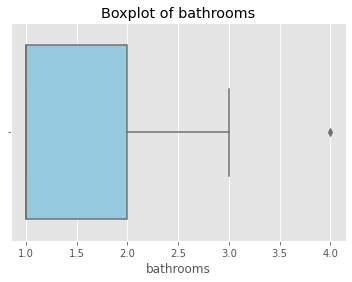

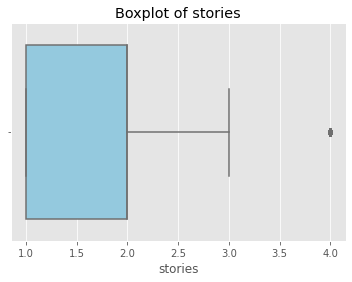

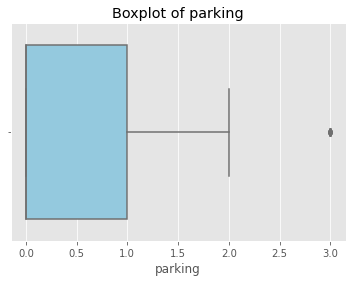

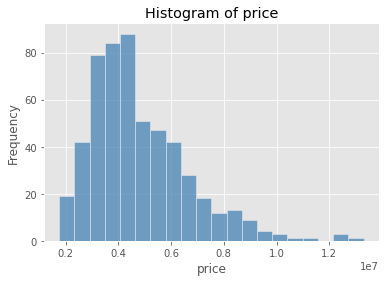

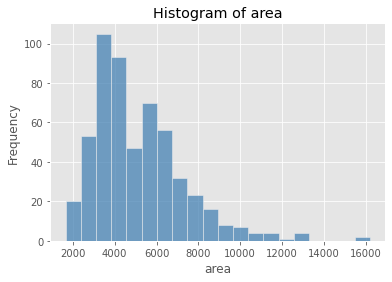

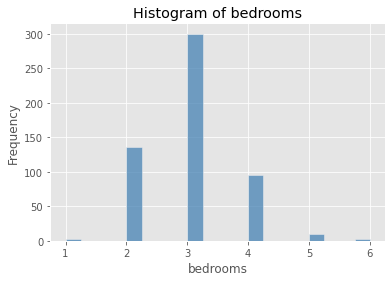

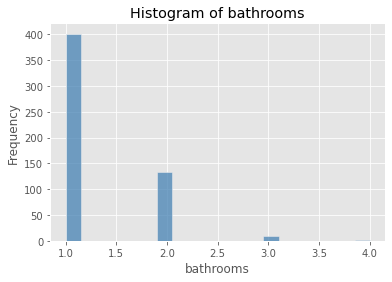

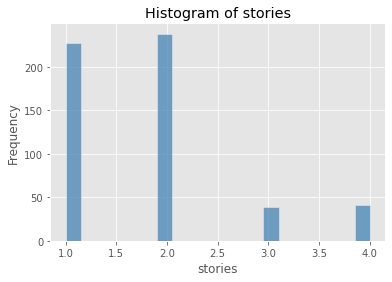

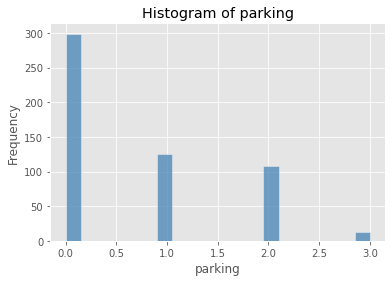

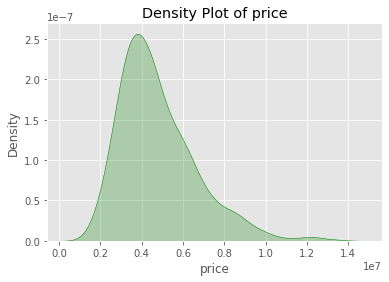

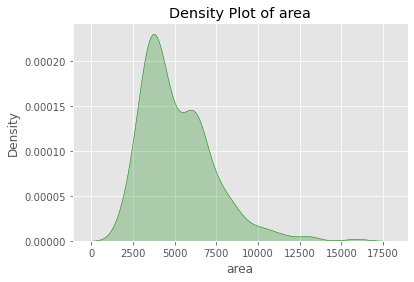

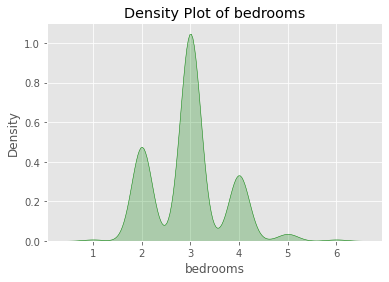

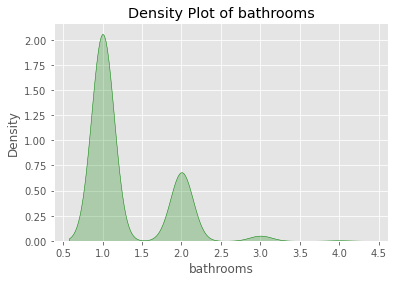

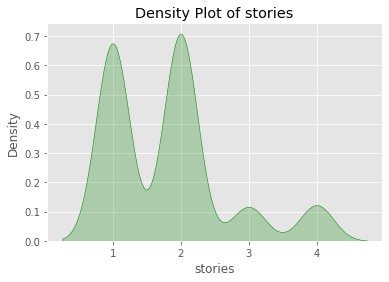

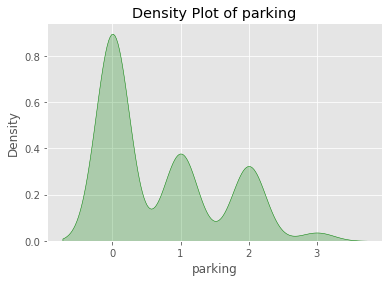

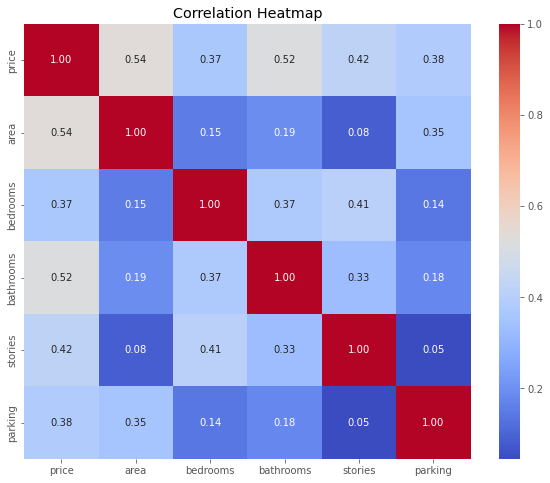

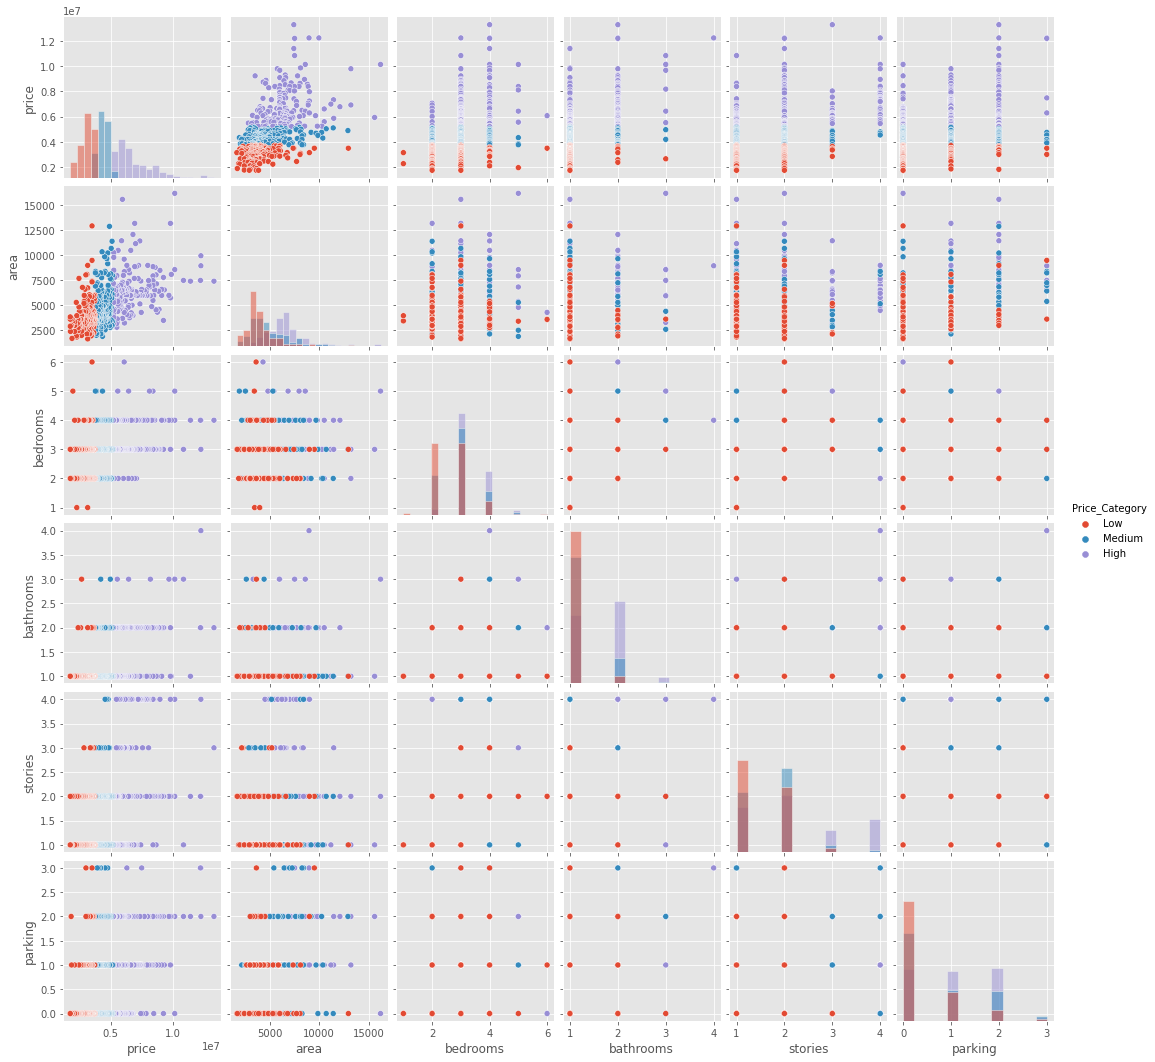

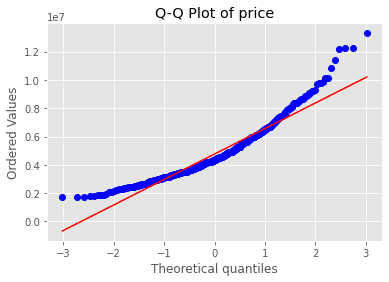

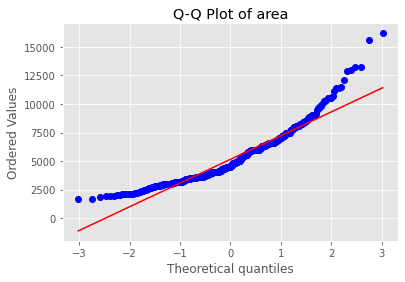

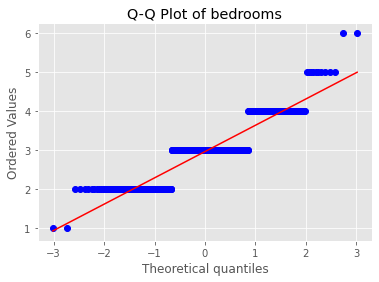

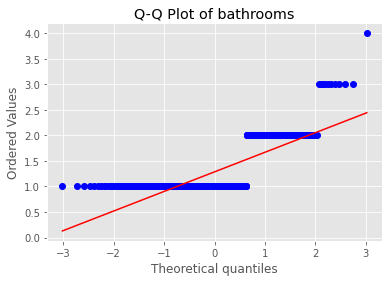

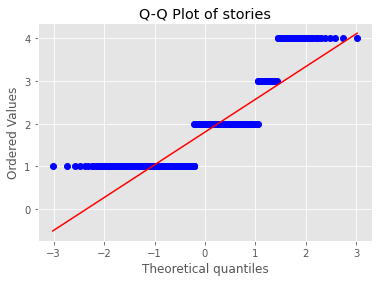

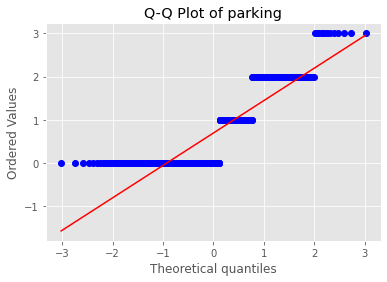

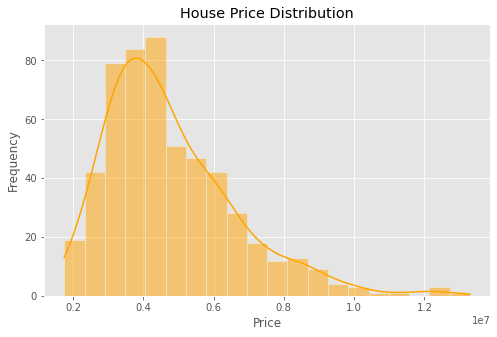


Analysis Completed Successfully!


In [1]:

!pip install pandas numpy scipy matplotlib seaborn

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import trim_mean, median_abs_deviation, probplot

plt.style.use('ggplot')


df = pd.read_csv("Housing.csv")

print("First 5 Rows:")
print(df.head())

print("\nDataset Info:")
print(df.info())

print("\nMissing Values:")
print(df.isnull().sum())


num_df = df.select_dtypes(include=np.number)

print("\nNumerical Columns:")
print(num_df.columns)


print("\n========== MEAN ==========")
for col in num_df.columns:
    print(f"{col}: {num_df[col].mean()}")

print("\n========== MEDIAN ==========")
for col in num_df.columns:
    print(f"{col}: {num_df[col].median()}")

print("\n========== TRIMMED MEAN ==========")
for col in num_df.columns:
    data = num_df[col].dropna()
    print(f"{col}: {trim_mean(data, 0.10)}")

print("\n========== WEIGHTED MEAN ==========")
for col in num_df.columns:
    data = num_df[col].dropna()
    weights = np.arange(1, len(data)+1)
    print(f"{col}: {np.average(data, weights=weights)}")


print("\n========== RANGE ==========")
for col in num_df.columns:
    print(f"{col}: {num_df[col].max() - num_df[col].min()}")

print("\n========== VARIANCE ==========")
for col in num_df.columns:
    print(f"{col}: {num_df[col].var()}")

print("\n========== STANDARD DEVIATION ==========")
for col in num_df.columns:
    print(f"{col}: {num_df[col].std()}")

print("\n========== INTERQUARTILE RANGE ==========")
for col in num_df.columns:
    Q1 = num_df[col].quantile(0.25)
    Q3 = num_df[col].quantile(0.75)
    print(f"{col}: {Q3 - Q1}")

print("\n========== MEDIAN ABSOLUTE DEVIATION ==========")
for col in num_df.columns:
    data = num_df[col].dropna()
    print(f"{col}: {median_abs_deviation(data)}")


for col in num_df.columns:
    plt.figure(figsize=(6,4))
    sns.boxplot(x=df[col], color="skyblue")
    plt.title(f"Boxplot of {col}")
    plt.xlabel(col)
    plt.show()


for col in num_df.columns:
    plt.figure(figsize=(6,4))
    sns.histplot(df[col].dropna(), bins=20, color="steelblue")
    plt.title(f"Histogram of {col}")
    plt.xlabel(col)
    plt.ylabel("Frequency")
    plt.show()


for col in num_df.columns:
    plt.figure(figsize=(6,4))
    sns.kdeplot(df[col].dropna(), fill=True, color="green")
    plt.title(f"Density Plot of {col}")
    plt.xlabel(col)
    plt.show()


plt.figure(figsize=(10,8))
sns.heatmap(num_df.corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()


if "price" in df.columns:
    # Convert price into categories for coloring
    df["Price_Category"] = pd.qcut(df["price"], q=3,
                                   labels=["Low","Medium","High"])

    sns.pairplot(df,
                 vars=num_df.columns,
                 hue="Price_Category",
                 diag_kind="hist")
else:
    sns.pairplot(num_df)

plt.show()


for col in num_df.columns:
    plt.figure(figsize=(6,4))
    probplot(df[col].dropna(), dist="norm", plot=plt)
    plt.title(f"Q-Q Plot of {col}")
    plt.show()


if "price" in df.columns:
    plt.figure(figsize=(8,5))
    sns.histplot(df["price"], bins=20, kde=True, color="orange")
    plt.title("House Price Distribution")
    plt.xlabel("Price")
    plt.ylabel("Frequency")
    plt.show()

print("\nAnalysis Completed Successfully!")